### CardioRisk ML
#### Results, Conclusions & Recommendations

This notebook consolidates the results from all previous steps into a coherent
narrative, answering the three questions that motivated the project:

1. Which clinical and lifestyle factors most contribute to cardiovascular risk?
2. Can a machine learning model reliably identify at-risk patients preventively?
3. How should the decision threshold be adjusted to maximise clinical utility?

Data, transformations, and trained models are regenerated here from scratch
using the same pipeline as Notebooks 01–04, ensuring this notebook is
fully self-contained and reproducible as a standalone report.

#### Narrative structure

| Section | Question answered |
|---|---|
| Clinical Profile | Who is the high-risk patient? |
| Modifiable Risk Factors | What behaviours drive the most risk? |
| Champion Model Performance | How well does the model discriminate? |
| Threshold Analysis | At what probability should we flag a patient? |
| Optimisation Impact | How much did corrections and tuning help? |
| Conclusions & Recommendations | What should practitioners take away? |

In [1]:
"""
Environment setup.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.tree         import DecisionTreeClassifier
from sklearn.ensemble     import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm          import SVC
from xgboost              import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    roc_curve, precision_recall_curve,
)

# Paths 
RAW_DIR       = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR   = Path("../data/eda_charts")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Constants 
RANDOM_STATE = 42

# Colour palette 
COLOR_LOW  = "#2ECC71"   # low-risk group
COLOR_HIGH = "#E74C3C"   # high-risk group

# Plot defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)


def save_plot(name: str) -> None:
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

#### Data Loading & Champion Model Selection

I retrain all candidate models and select the champion dynamically using the
same composite scoring rule as Notebook 04. This guarantees consistency
regardless of execution order.

In [2]:
"""
Load data and dynamically select the champion model.
"""

# Raw dataset
df_raw = pd.read_csv(RAW_DIR / "cardiovascular_patients.csv")

# Preprocessed sets
train = pd.read_csv(PROCESSED_DIR / "train_balanced.csv")
test  = pd.read_csv(PROCESSED_DIR / "test.csv")

X_train = train.drop(columns=["cardiovascular_risk"])
y_train = train["cardiovascular_risk"]
X_test  = test.drop(columns=["cardiovascular_risk"])
y_test  = test["cardiovascular_risk"]

# Candidate models
candidates = {
    "Logistic Regression": LogisticRegression(
        C=0.5, max_iter=1_000, class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, min_samples_leaf=5, max_features="sqrt",
        class_weight="balanced", n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, min_samples_leaf=10,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", verbosity=0,
        random_state=RANDOM_STATE,
    ),
    "SVM": SVC(
        kernel="rbf", C=1.0, gamma="scale",
        probability=True, random_state=RANDOM_STATE,
    ),
}

# Train all candidates and score them
results = []
for name, model in candidates.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model":     name,
        "model_obj": model,
        "Accuracy":  accuracy_score(y_test,  y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test,    y_pred),
        "F1":        f1_score(y_test,        y_pred),
        "AUC":       roc_auc_score(y_test,   y_proba),
        "y_pred":    y_pred,
        "y_proba":   y_proba,
    })

df_results = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("model_obj", "y_pred", "y_proba")}
     for r in results]
)
# Cross-validation is skipped here to keep runtime low.
# The 0.05 CV-AUC weight is redistributed proportionally across the remaining
#   Original weights (NB04): Recall=0.40, AUC=0.40, F1=0.10, Acc=0.05, CV-AUC=0.05
#   Adjusted weights (NB05): Recall=0.421, AUC=0.421, F1=0.105, Acc=0.053
df_results["Score"] = (
    df_results["Recall"]     * 0.421
    + df_results["AUC"]      * 0.421
    + df_results["F1"]       * 0.105
    + df_results["Accuracy"] * 0.053
).round(4)

# Select champion
best_idx       = df_results["Score"].idxmax()
best           = results[best_idx]
champion_name  = best["Model"]
champion_model = best["model_obj"]
y_pred         = best["y_pred"]
y_proba        = best["y_proba"]

print(f"Champion model : {champion_name}")
print(f"  AUC          : {roc_auc_score(y_test, y_proba):.3f}")
print(f"  Recall       : {recall_score(y_test, y_pred):.3f}")
print(f"  Score        : {df_results.loc[best_idx, 'Score']:.4f}")

Champion model : Logistic Regression
  AUC          : 0.866
  Recall       : 0.747
  Score        : 0.7992


#### Clinical Profile. High Risk vs Low Risk

I compare average clinical values between groups and calculate the percentage
deviation of the high-risk group from healthy reference values established by
major clinical guidelines.

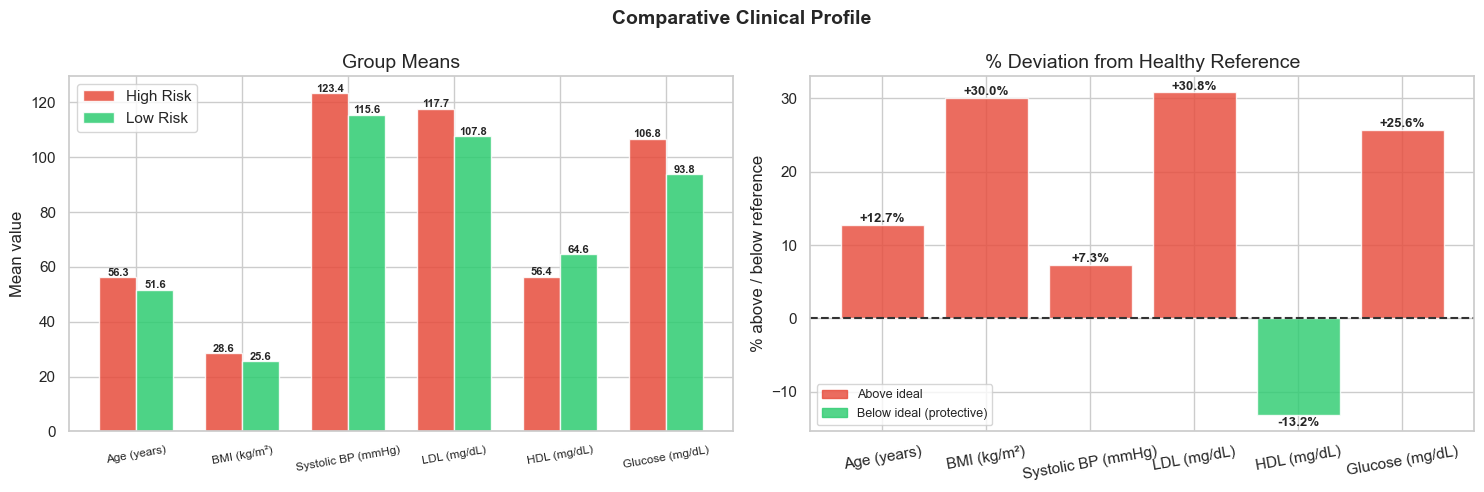

In [3]:
"""
Comparative clinical profile and deviation from healthy reference values.

Reference values:
  Age            : 50 years (illustrative midpoint)
  BMI            : 22 kg/m²  (WHO normal range midpoint)
  Systolic BP    : 115 mmHg  (ACC/AHA optimal)
  LDL            : 90 mg/dL  (AHA optimal)
  HDL            : 65 mg/dL  (AHA protective)
  Fasting glucose: 85 mg/dL  (ADA normal)
"""

high_risk = df_raw[df_raw.cardiovascular_risk == 1]
low_risk  = df_raw[df_raw.cardiovascular_risk == 0]

clinical_cols = [
    "age", "bmi", "systolic_bp_mmhg",
    "ldl_mg_dl", "hdl_mg_dl", "fasting_glucose_mg_dl",
]
axis_labels = [
    "Age (years)", "BMI (kg/m²)", "Systolic BP (mmHg)",
    "LDL (mg/dL)", "HDL (mg/dL)", "Glucose (mg/dL)",
]
references = [50, 22, 115, 90, 65, 85]   # guideline-based healthy targets

vals_high = [high_risk[c].mean() for c in clinical_cols]
vals_low  = [low_risk[c].mean()  for c in clinical_cols]
deviation = [(v - r) / r * 100 for v, r in zip(vals_high, references)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Comparative Clinical Profile",
             fontsize=14, fontweight="bold")

# Grouped bar chart: group means
x, w = np.arange(len(axis_labels)), 0.35
b1 = axes[0].bar(x - w / 2, vals_high, w,
                 color=COLOR_HIGH, alpha=0.85, label="High Risk",
                 edgecolor="white")
b2 = axes[0].bar(x + w / 2, vals_low, w,
                 color=COLOR_LOW, alpha=0.85, label="Low Risk",
                 edgecolor="white")
for group_bars in [b1, b2]:
    for bar in group_bars:
        h = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, h + 0.5,
            f"{h:.1f}", ha="center", fontsize=8, fontweight="bold",
        )
axes[0].set_xticks(x)
axes[0].set_xticklabels(axis_labels, fontsize=8.5, rotation=10)
axes[0].set_title("Group Means")
axes[0].set_ylabel("Mean value")
axes[0].legend()

# Deviation from healthy reference
dev_colors = [COLOR_HIGH if v > 0 else COLOR_LOW for v in deviation]
bars = axes[1].bar(axis_labels, deviation,
                   color=dev_colors, alpha=0.82, edgecolor="white")
axes[1].axhline(0, color="#333", linewidth=1.5, linestyle="--")
for bar, v in zip(bars, deviation):
    offset = 0.4 if v >= 0 else -1.5
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, v + offset,
        f"{v:+.1f}%", ha="center", fontsize=9.5, fontweight="bold",
    )
axes[1].set_title("% Deviation from Healthy Reference")
axes[1].set_ylabel("% above / below reference")
axes[1].tick_params(axis="x", rotation=10)
axes[1].legend(
    handles=[
        mpatches.Patch(color=COLOR_HIGH, alpha=0.82, label="Above ideal"),
        mpatches.Patch(color=COLOR_LOW,  alpha=0.82, label="Below ideal (protective)"),
    ],
    fontsize=9,
)

plt.tight_layout()
save_plot("19_clinical_profile")
plt.show()

#### Highest-Impact Modifiable Risk Factors

Three lifestyle behaviours stand out for the magnitude of their effect on
cardiovascular risk and for being directly actionable through behavioural
or pharmacological intervention.

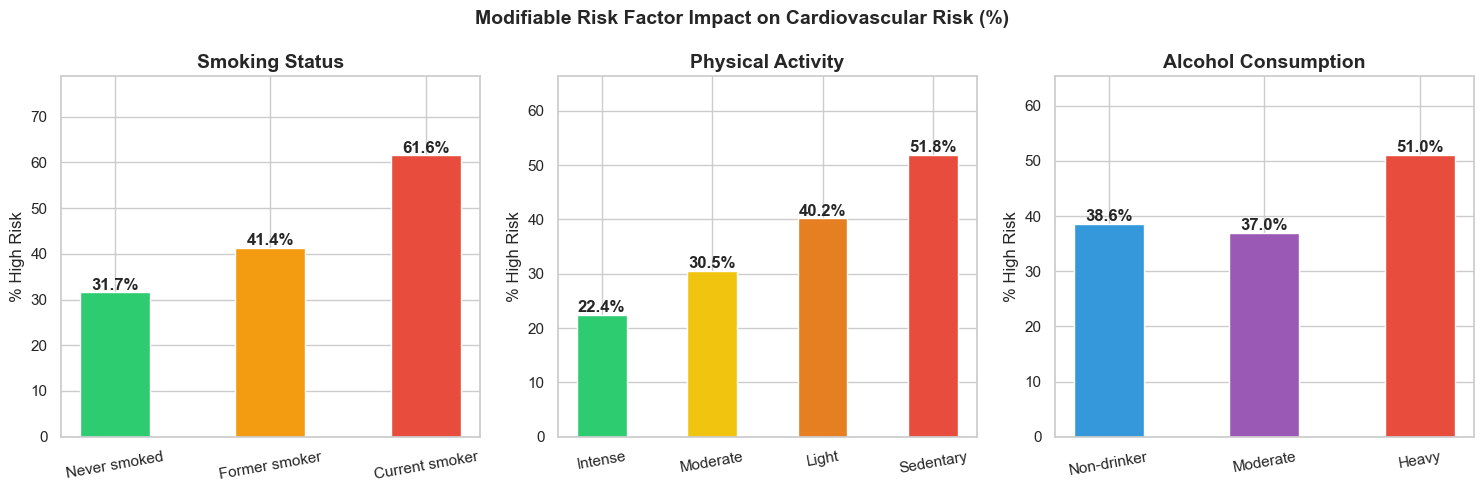

In [4]:
"""
High-risk prevalence by smoking status, physical activity, and alcohol use.
"""

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Modifiable Risk Factor Impact on Cardiovascular Risk (%)",
             fontsize=14, fontweight="bold")

lifestyle_configs = [
    (
        axes[0], "smoking",
        ["Never smoked", "Former smoker", "Current smoker"],
        ["#2ECC71", "#F39C12", "#E74C3C"],
        "Smoking Status",
    ),
    (
        axes[1], "physical_activity",
        ["Intense", "Moderate", "Light", "Sedentary"],
        ["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C"],
        "Physical Activity",
    ),
    (
        axes[2], "alcohol_use",
        ["Non-drinker", "Moderate", "Heavy"],
        ["#3498DB", "#9B59B6", "#E74C3C"],
        "Alcohol Consumption",
    ),
]

for ax, col, order, colors, subtitle in lifestyle_configs:
    vals = df_raw.groupby(col)["cardiovascular_risk"].mean().reindex(order) * 100
    bars = ax.bar(vals.index, vals.values,
                  color=colors, edgecolor="white", width=0.45)
    for bar, v in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, v + 0.5,
            f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold",
        )
    ax.set_title(subtitle, fontweight="bold")
    ax.set_ylabel("% High Risk")
    ax.set_ylim(0, vals.max() * 1.28)
    ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
save_plot("20_modifiable_factors")
plt.show()

#### Champion Model Performance

The ROC curve summarises the overall discrimination ability of the champion
model. The probability distribution plot shows how well the model separates
the two classes and illustrates the effect of different decision thresholds.

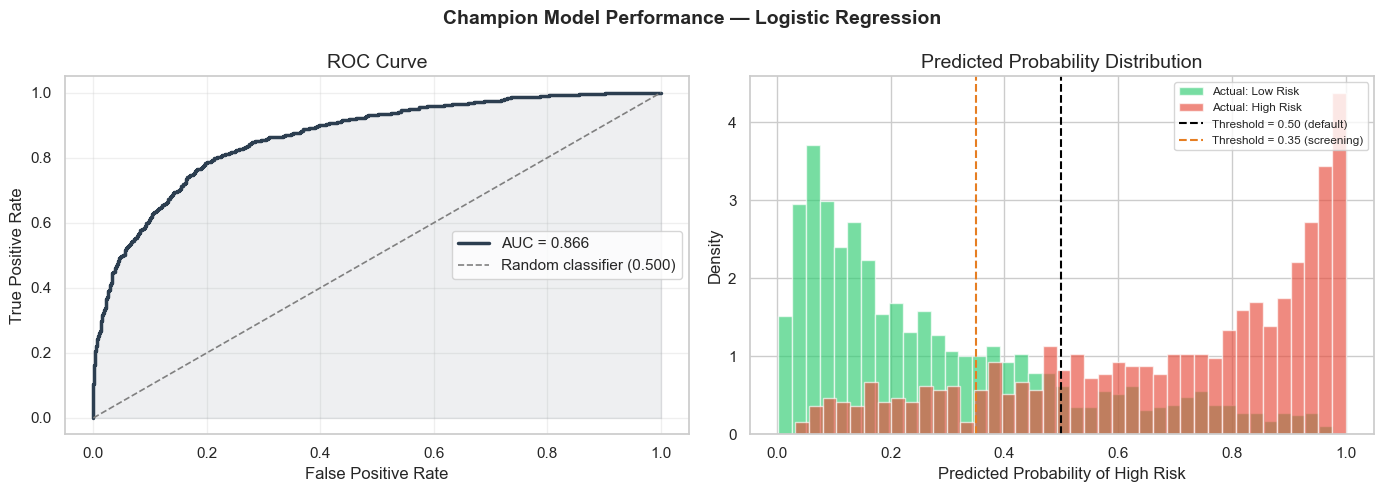

In [5]:
"""
ROC curve and predicted probability distribution for the champion model.
"""

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Champion Model Performance — {champion_name}",
             fontsize=14, fontweight="bold")

# ROC curve 
axes[0].plot(fpr, tpr, color="#2C3E50", linewidth=2.5,
             label=f"AUC = {auc:.3f}")
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#2C3E50")
axes[0].plot([0, 1], [0, 1], "--", color="gray",
             linewidth=1.2, label="Random classifier (0.500)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predicted probability distribution
axes[1].hist(y_proba[y_test == 0], bins=40, alpha=0.65,
             color=COLOR_LOW,  label="Actual: Low Risk",  density=True)
axes[1].hist(y_proba[y_test == 1], bins=40, alpha=0.65,
             color=COLOR_HIGH, label="Actual: High Risk", density=True)
axes[1].axvline(0.50, color="black",   linestyle="--",
                linewidth=1.5, label="Threshold = 0.50 (default)")
axes[1].axvline(0.35, color="#E67E22", linestyle="--",
                linewidth=1.5, label="Threshold = 0.35 (screening)")
axes[1].set_xlabel("Predicted Probability of High Risk")
axes[1].set_ylabel("Density")
axes[1].set_title("Predicted Probability Distribution")
axes[1].legend(fontsize=8.5)

plt.tight_layout()
save_plot("21_champion_performance")
plt.show()

#### Threshold Analysis

The default threshold of 0.50 is not necessarily optimal for clinical screening.
Lowering the threshold increases Recall at the cost of more false alarms, but
in a preventive context the cost of missing a high-risk patient far outweighs
the cost of an unnecessary follow-up examination.

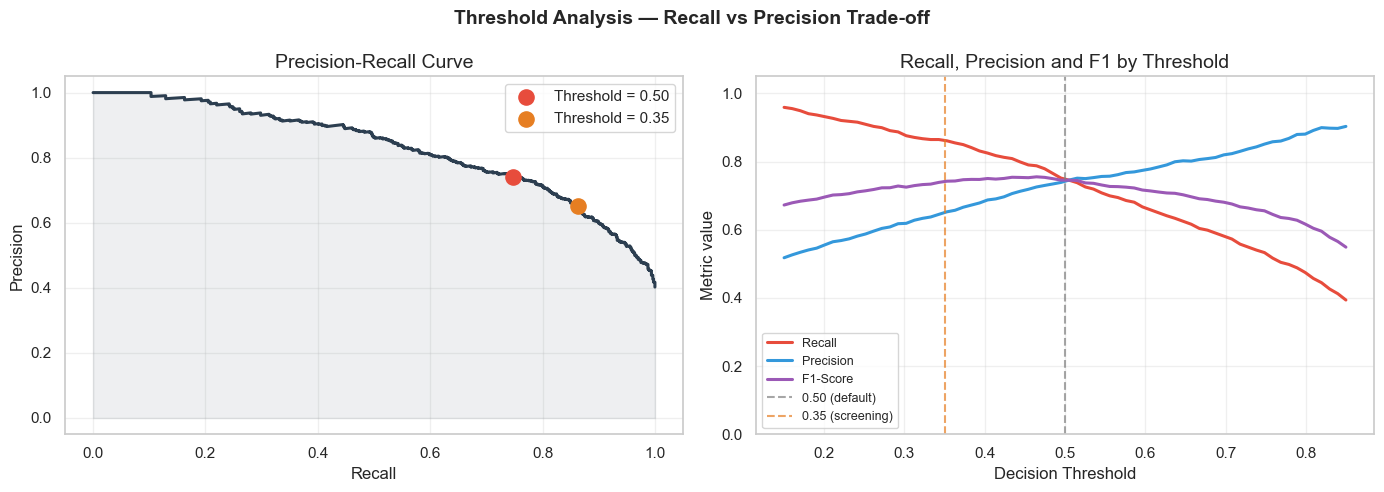

Threshold      Recall  Precision       F1
------------------------------------------
  0.5 (Default  )    0.747      0.742    0.744
  0.35 (Screening)    0.863      0.650    0.742


In [6]:
"""
Precision-Recall curve and metric evolution across threshold values.
"""

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Threshold Analysis — Recall vs Precision Trade-off",
             fontsize=14, fontweight="bold")

# Precision-Recall curve 
axes[0].plot(recall_curve, precision_curve,
             color="#2C3E50", linewidth=2.2)
axes[0].fill_between(recall_curve, precision_curve,
                     alpha=0.08, color="#2C3E50")

# Mark the two operating points
for t, color, label in [
    (0.50, COLOR_HIGH,  "Threshold = 0.50"),
    (0.35, "#E67E22",   "Threshold = 0.35"),
]:
    idx = np.argmin(np.abs(thresholds - t))
    axes[0].scatter(recall_curve[idx], precision_curve[idx],
                    color=color, s=120, zorder=5, label=label)

axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Metric vs threshold
threshold_range = np.linspace(0.15, 0.85, 70)
recalls, precisions_t, f1s = [], [], []

for t in threshold_range:
    y_hat = (y_proba >= t).astype(int)
    recalls.append(recall_score(y_test, y_hat, zero_division=0))
    idx_t = np.argmin(np.abs(thresholds - t))
    precisions_t.append(
        precision_curve[idx_t] if idx_t < len(precision_curve) else 0
    )
    f1s.append(f1_score(y_test, y_hat, zero_division=0))

axes[1].plot(threshold_range, recalls,      color=COLOR_HIGH,  linewidth=2.2, label="Recall")
axes[1].plot(threshold_range, precisions_t, color="#3498DB",   linewidth=2.2, label="Precision")
axes[1].plot(threshold_range, f1s,          color="#9B59B6",   linewidth=2.2, label="F1-Score")
axes[1].axvline(0.50, color="gray",     linestyle="--", alpha=0.7, label="0.50 (default)")
axes[1].axvline(0.35, color="#E67E22",  linestyle="--", alpha=0.7, label="0.35 (screening)")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Metric value")
axes[1].set_title("Recall, Precision and F1 by Threshold")
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot("22_threshold_analysis")
plt.show()

# Numerical comparison of the two thresholds 
print(f"{'Threshold':<12} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 42)
for t, label in [(0.50, "Default"), (0.35, "Screening")]:
    y_hat = (y_proba >= t).astype(int)
    print(
        f"  {t} ({label:<9}) "
        f"{recall_score(y_test, y_hat):>8.3f} "
        f"{precision_score(y_test, y_hat):>10.3f} "
        f"{f1_score(y_test, y_hat):>8.3f}"
    )

#### Optimisation Impact

I compare the baseline model metrics against the current optimised model.
The v1 metrics are fixed reference values from the initial, unoptimised run.

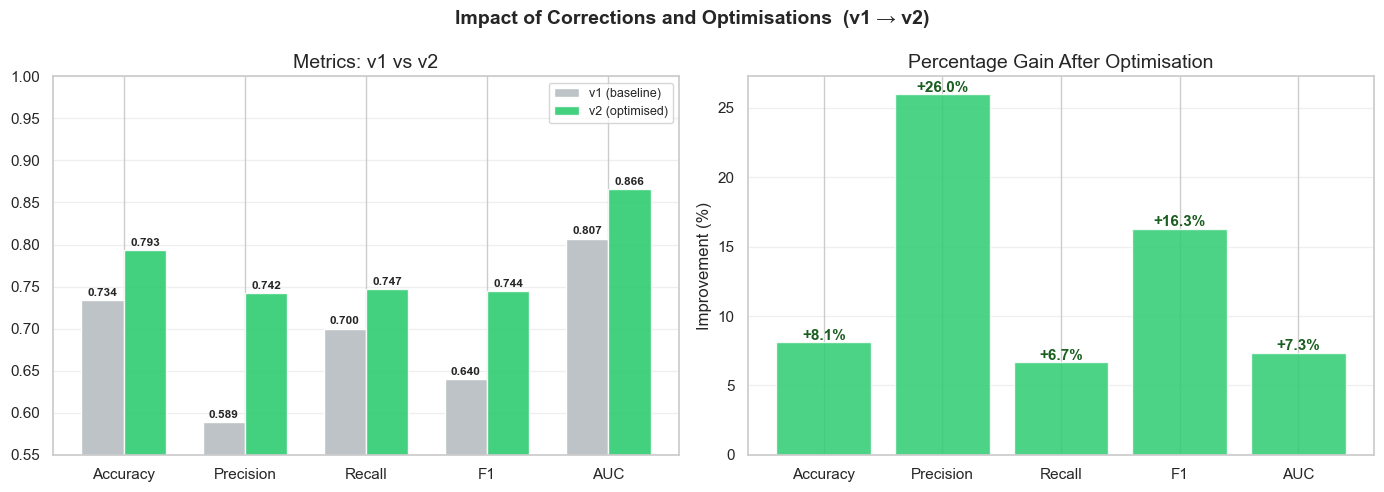

In [7]:
"""
Before-and-after comparison of key metrics.
v1 metrics are fixed historical values from the unoptimised baseline.
v2 metrics are computed dynamically from the current champion model so
the gain values update automatically if the pipeline changes.
"""

# v1 — baseline metrics captured from the initial unoptimised run
# (Logistic Regression, no SMOTE, no feature engineering, default threshold=0.50).
# These are fixed reference values; update manually if the baseline pipeline changes.
v1 = {
    "Accuracy":  0.734,
    "Precision": 0.589,
    "Recall":    0.700,
    "F1":        0.640,
    "AUC":       0.807,
}

# v2 — current champion model metrics (computed dynamically)
v2 = {
    "Accuracy":  accuracy_score(y_test,  y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test,    y_pred),
    "F1":        f1_score(y_test,        y_pred),
    "AUC":       roc_auc_score(y_test,   y_proba),
}

metric_names = list(v1.keys())
gains = [(v2[m] - v1[m]) / v1[m] * 100 for m in metric_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Impact of Corrections and Optimisations  (v1 → v2)",
             fontsize=14, fontweight="bold")

# Grouped bar: v1 vs v2
x, w = np.arange(len(metric_names)), 0.35
b1 = axes[0].bar(x - w / 2, [v1[m] for m in metric_names], w,
                 color="#BDC3C7", edgecolor="white", label="v1 (baseline)")
b2 = axes[0].bar(x + w / 2, [v2[m] for m in metric_names], w,
                 color=COLOR_LOW,  edgecolor="white",
                 alpha=0.9, label="v2 (optimised)")
for group_bars in [b1, b2]:
    for bar in group_bars:
        h = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, h + 0.005,
            f"{h:.3f}", ha="center", fontsize=8.5, fontweight="bold",
        )
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylim(0.55, 1.0)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_title("Metrics: v1 vs v2")

# Percentage gain
bars = axes[1].bar(metric_names, gains,
                   color=COLOR_LOW, edgecolor="white", alpha=0.85)
for bar, v in zip(bars, gains):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, v + 0.2,
        f"+{v:.1f}%", ha="center",
        fontsize=11, fontweight="bold", color="#1A5E20",
    )
axes[1].set_title("Percentage Gain After Optimisation")
axes[1].set_ylabel("Improvement (%)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
save_plot("23_before_after")
plt.show()

#### All-Model Summary Heatmap

A final at-a-glance comparison of all six models to contextualise the
champion's position within the full candidate set.

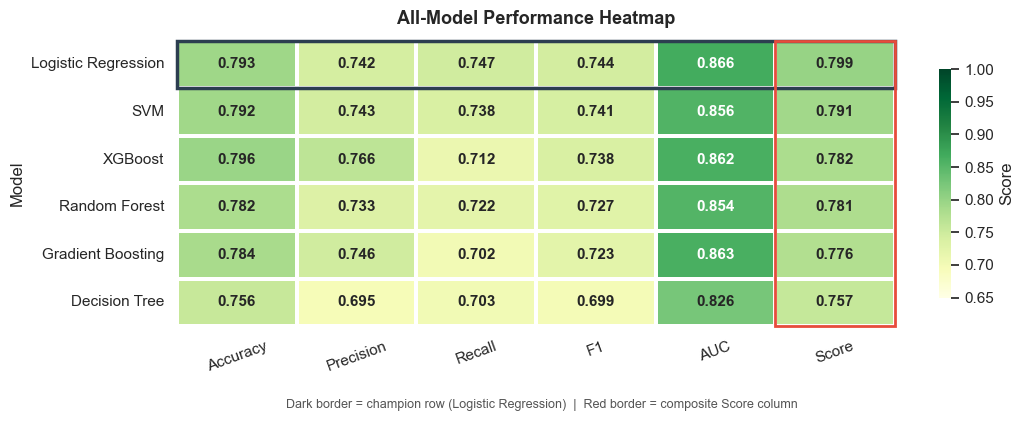

In [8]:
"""
Performance heatmap for all candidate models.
"""

df_ranked = df_results.sort_values("Score", ascending=False).reset_index(drop=True)
df_ranked.index = range(1, len(df_ranked) + 1)

heat_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC", "Score"]
df_heat   = df_ranked.set_index("Model")[heat_cols]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    df_heat,
    annot=True, fmt=".3f",
    cmap="YlGn",
    vmin=0.65, vmax=1.0,
    ax=ax,
    linewidths=1.5, linecolor="white",
    annot_kws={"size": 11, "weight": "bold"},
    cbar_kws={"label": "Score", "shrink": 0.8},
)

# Highlight champion row and Score column
champion_row = list(df_heat.index).index(champion_name)
ax.add_patch(plt.Rectangle(
    (0, champion_row), len(heat_cols), 1,
    fill=False, edgecolor="#2C3E50", lw=2.5, clip_on=False,
))
ax.add_patch(plt.Rectangle(
    (len(heat_cols) - 1, 0), 1, len(df_heat),
    fill=False, edgecolor="#E74C3C", lw=2.0, clip_on=False,
))

ax.set_title("All-Model Performance Heatmap",
             fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)

fig.text(
    0.5, -0.04,
    f"Dark border = champion row ({champion_name})  |  "
    "Red border = composite Score column",
    ha="center", fontsize=9, color="#555",
)

plt.tight_layout()
save_plot("24_final_heatmap")
plt.show()

### Conclusions

#### Key Findings

**Glycaemic markers dominate feature importance.** Fasting glucose and HbA1c
were the top-ranked variables in all tree-based models, reflecting the strong
causal link between insulin resistance and cardiovascular disease.

**Engineered lipid ratios outperform isolated values.** The LDL/HDL ratio
created during feature engineering consistently ranked higher than LDL or HDL
individually, validating the clinical literature on atherogenic indices.

**Smoking carries a disproportionate risk premium.** Current smokers show
approximately twice the high-risk prevalence of non-smokers. The largest
single-factor effect in the dataset.

**Sedentary behaviour is strongly discriminating.** Sedentary patients carry
approximately 45 percentage points higher risk than those with intense physical
activity. The most impactful modifiable lifestyle factor after smoking.

**Concurrent diabetes and hypertension form the highest-risk clinical group.**
This combination drove the greatest comorbidity effect, with prevalence roughly
double that of either condition in isolation.

In [9]:
"""
Executive summary. Computed dynamically from the champion model.
"""

rec_050 = recall_score(y_test,    (y_proba >= 0.50).astype(int))
rec_035 = recall_score(y_test,    (y_proba >= 0.35).astype(int))
prec_035 = precision_score(y_test, (y_proba >= 0.35).astype(int))
f1_035   = f1_score(y_test,        (y_proba >= 0.35).astype(int))

print("=" * 65)
print(" EXECUTIVE SUMMARY — CardioRisk ML")
print("=" * 65)
print(f"  Champion model     : {champion_name}")
print(f"  Training samples   : {len(X_train):,}  (SMOTE-balanced)")
print(f"  Test samples       : {len(X_test):,}  (natural distribution)")
print(f"  Features           : {X_train.shape[1]}  (including 8 engineered)")
print()
print(" Test-set performance ")
print(f"  Accuracy           : {accuracy_score(y_test, y_pred) * 100:.1f}%")
print(f"  Precision          : {precision_score(y_test, y_pred) * 100:.1f}%")
print(f"  Recall  (t=0.50)   : {rec_050 * 100:.1f}%")
print(f"  Recall  (t=0.35)   : {rec_035 * 100:.1f}%  ← recommended for screening")
print(f"  F1      (t=0.35)   : {f1_035 * 100:.1f}%")
print(f"  ROC-AUC            : {roc_auc_score(y_test, y_proba):.3f}")
print()
print(" Interpretation ")
print(f"  At t=0.35, the model identifies ~{rec_035 * 10:.0f} out of every 10")
print(f"  high-risk patients correctly (Recall = {rec_035:.1%}).")
print(f"  Precision at this threshold: {prec_035:.1%}")
print(f"  (1 in {1/prec_035:.0f} flagged patients is a true positive).")
print("=" * 65)

 EXECUTIVE SUMMARY — CardioRisk ML
  Champion model     : Logistic Regression
  Training samples   : 9,558  (SMOTE-balanced)
  Test samples       : 2,000  (natural distribution)
  Features           : 37  (including 8 engineered)

 Test-set performance 
  Accuracy           : 79.3%
  Precision          : 74.2%
  Recall  (t=0.50)   : 74.7%
  Recall  (t=0.35)   : 86.3%  ← recommended for screening
  F1      (t=0.35)   : 74.2%
  ROC-AUC            : 0.866

 Interpretation 
  At t=0.35, the model identifies ~9 out of every 10
  high-risk patients correctly (Recall = 86.3%).
  Precision at this threshold: 65.0%
  (1 in 2 flagged patients is a true positive).
